In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_val.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_train.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/zero-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_test.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal375.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal341.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal374.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal383.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-class

In [2]:
import os

# Find the exact path where the class folders live
for root, dirs, files in os.walk("/kaggle/input"):
    if "cardboard" in dirs:
        print("Copy and paste this path into your script:")
        print(f"DATA_DIR = '{root}'")
        break

Copy and paste this path into your script:
DATA_DIR = '/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification'


In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split

# 1. Environment Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. Preprocessing & Data Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# 3. Load & Split Dataset
DATA_DIR = "/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification"  # Path to unzipped dataset folder
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

# Train / Validation Split (80% / 20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Assign specific transforms to each split
train_subset.dataset.transform = data_transforms['train']
val_subset.dataset.transform = data_transforms['val']

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

# 4. Model Setup (ResNet-18 Fine-tuning)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze lower layers to retain ImageNet features
for param in model.parameters():
    param.requires_grad = False

# Replace final Linear layer with 5 outputs
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# 5. Optimization Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 6. Training & Validation Loop
num_epochs = 10
best_acc = 0.0

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("-" * 25)

    # --- Training Phase ---
    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.double() / train_size
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    # --- Validation Phase ---
    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / val_size
    val_acc = val_corrects.double() / val_size
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save best checkpoint
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "waste_classifier_resnet18.pth")
        print("--> Saved best model checkpoint.")

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.4f}")

Training on device: cuda
Detected 6 classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s] 


Epoch 1/10
-------------------------
Train Loss: 1.3131 | Train Acc: 0.5136
Val Loss:   0.9382 | Val Acc:   0.7233
--> Saved best model checkpoint.
Epoch 2/10
-------------------------
Train Loss: 0.8396 | Train Acc: 0.7284
Val Loss:   0.7550 | Val Acc:   0.7530
--> Saved best model checkpoint.
Epoch 3/10
-------------------------
Train Loss: 0.6843 | Train Acc: 0.7778
Val Loss:   0.6839 | Val Acc:   0.7688
--> Saved best model checkpoint.
Epoch 4/10
-------------------------
Train Loss: 0.6147 | Train Acc: 0.7942
Val Loss:   0.6386 | Val Acc:   0.7925
--> Saved best model checkpoint.
Epoch 5/10
-------------------------
Train Loss: 0.5596 | Train Acc: 0.8159
Val Loss:   0.6363 | Val Acc:   0.7806
Epoch 6/10
-------------------------
Train Loss: 0.5175 | Train Acc: 0.8323
Val Loss:   0.5900 | Val Acc:   0.8004
--> Saved best model checkpoint.
Epoch 7/10
-------------------------
Train Loss: 0.4897 | Train Acc: 0.8352
Val Loss:   0.5900 | Val Acc:   0.7945
Epoch 8/10
-------------------

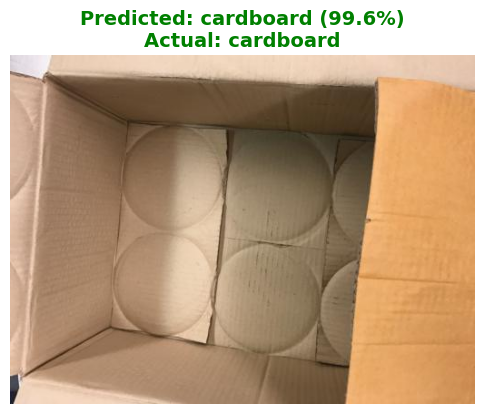

In [16]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# 1. Select a random image from the dataset
random_path, true_idx = random.choice(full_dataset.samples)
true_class = class_names[true_idx]

# 2. Load raw image and prepare model input
raw_img = Image.open(random_path).convert('RGB')
input_tensor = data_transforms['val'](raw_img).unsqueeze(0).to(device)

# 3. Run prediction
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs[0], dim=0)
    pred_idx = torch.argmax(probabilities).item()
    confidence = probabilities[pred_idx].item() * 100
    pred_class = class_names[pred_idx]

# 4. Display image and classification result
plt.figure(figsize=(6, 6))
plt.imshow(raw_img)
plt.axis('off')

# Green title if correct, red title if misclassified
title_color = 'green' if pred_class == true_class else 'red'
plt.title(
    f"Predicted: {pred_class} ({confidence:.1f}%)\nActual: {true_class}",
    color=title_color,
    fontsize=14,
    fontweight='bold'
)
plt.show()

In [21]:
test_transform = transforms.Compose([
    transforms.Resize((244,244)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_single_image(image_path, model, class_names, device):
    # Load image and convert to RGB
    raw_img = Image.open(image_path).convert('RGB')
    
    # Preprocess and add batch dimension (Shape becomes: [1, 3, 224, 224])
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)
    
    # Model inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs[0], dim=0)
        confidence, pred_idx = torch.max(probabilities, dim=0)
        
    pred_class = class_names[pred_idx.item()]
    confidence_score = confidence.item() * 100

    # Display image and prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} ({confidence_score:.2f}%)", fontsize=14, color="blue")
    plt.show()
    
    return pred_class, confidence_score

In [22]:
# Pass your image path, loaded model, list of class names, and compute device
image_path = "/kaggle/working/my_test_plastic_bottle.jpg"  # Path to your new image
predict_single_image(image_path, model, class_names, device)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/my_test_plastic_bottle.jpg'

In [23]:
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predict_from_url(url, model, class_names, device):
    # Fetch image from web (headers prevent 403 forbidden errors from some servers)
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    
    if response.status_code != 200:
        print(f"Failed to fetch image. HTTP Status Code: {response.status_code}")
        return

    # Load image from byte stream
    raw_img = Image.open(BytesIO(response.content)).convert('RGB')
    
    # Preprocess tensor (uses validation transforms defined earlier)
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)
    
    # Model inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs[0], dim=0)
        confidence, pred_idx = torch.max(probabilities, dim=0)
        
    pred_class = class_names[pred_idx.item()]
    confidence_score = confidence.item() * 100

    # Plot image and result
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} ({confidence_score:.2f}%)", fontsize=14, color="blue")
    plt.show()

    return pred_class, confidence_score

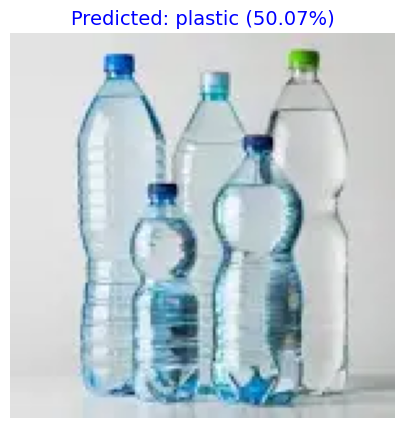

('plastic', 50.07235407829285)

In [25]:
# Pass any direct image URL (.jpg / .png)
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSzgJj5stRjeHLGctXh0jxJQNAfYEMKsvjmIa1rR4hXWWOEmaLzD27-_PFv-2Xhk-HfZZfOSZs43GZKTqHKzrzEVNa_3hIq4EIUsjS2&s&ec=121970951"
predict_from_url(img_url, model, class_names, device)